# Импорт библиотек

In [86]:
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from string import punctuation
import matplotlib.pyplot as plt
import pymorphy2
import re
import pickle
import joblib
import sklearn
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from keras.preprocessing import text, sequence
from tensorflow.keras import utils
from keras.layers import GRU, Bidirectional, GlobalAveragePooling1D, GlobalMaxPooling1D
from keras.layers import Input, Dense, Embedding, SpatialDropout1D, concatenate
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


from keras.models import Model
from tensorflow.keras.models import Sequential
from keras.layers import Input, Dense, Embedding, SpatialDropout1D, concatenate
from keras.layers import GRU, Bidirectional, GlobalAveragePooling1D, GlobalMaxPooling1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, Bidirectional, LSTM, GRU
from keras.preprocessing import text, sequence
from keras.callbacks import Callback
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error, r2_score
nltk.download('stopwords')

# Инициализируем морфологический анализатор
morph = pymorphy2.MorphAnalyzer()

# Стоп-слова и пунктуация
russian_stopwords = set(stopwords.words('russian'))
punctuation = punctuation + '—–«»…'

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Пользователь\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Функция для очистки текста
def clean_text(text):
    text = str(text).lower()
    text = text.replace('ё', 'е')
    text = re.sub(r'[^а-яa-z\s]', ' ', text)
    text = re.sub('((www\.[^\s]+)|(https?://[^\s]+))', 'URL', text)
    text = re.sub(' +', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

Оставляет только русские буквы, убирает цифры, знаки препинания.

In [3]:
def lemmatize_text(text):
    words = text.split()
    lemmatized_words = []
    for word in words:
        if word not in russian_stopwords and word not in punctuation and len(word) > 2:
            lemmatized_word = morph.parse(word)[0].normal_form
            lemmatized_words.append(lemmatized_word)
    return ' '.join(lemmatized_words)

Проводим слова к нормальной форме

In [4]:
def creat_df():
    data_list = []
    with open("dataset.txt", encoding = 'utf-8') as file:
        for line in file:
            labels = line.split()[0]
            text = line[len(labels)+1:].strip()
            labels = labels.split(",")
            mask = [1 if "__label__NORMAL" in labels else 0,
                    1 if "__label__INSULT" in labels else 0,
                    1 if "__label__THREAT" in labels else 0,
                    1 if "__label__OBSCENITY" in labels else 0]
            data_list.append((text, *mask))
    return pd.DataFrame(data_list, columns=["comment", "normal", "insult", "threat", "obscenity"])

Загрузка датасета с классификациий комментариев

In [5]:
df = creat_df()
df.head(10)

,comment,normal,insult,threat,obscenity
0,скотина! что сказать,0,1,0,0
1,я сегодня проезжала по рабочей и между домами ...,1,0,0,0
2,очередной лохотрон. зачем придумывать очередно...,1,0,0,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",1,0,0,0
4,а когда мы статус агрогородка получили?,1,0,0,0
5,2 августа поздно вечером нашли вот такую потер...,1,0,0,0
6,вчера надыбала новые стикеры #u2a94ec7fabs#,1,0,0,0
7,заколоть этого плешивого урода что бы крякнул ...,0,1,1,0
8,а еще на стоянке никто не проверяет безопаснос...,1,0,0,0
9,"красота..!! если есть, что показать??!! почему...",1,0,0,0


In [ ]:
%%time
df.to_csv('toxic_comment.csv', index=False)

Сохраняем датасет для использования в программе

In [6]:
df['lema_text'] = df['comment'].apply(clean_text).apply(lemmatize_text)

In [7]:
df['comment'].head(10)

0                                 скотина! что сказать
1    я сегодня проезжала по рабочей и между домами ...
2    очередной лохотрон. зачем придумывать очередно...
3    ретро дежавю ... сложно понять чужое сердце , ...
4              а когда мы статус агрогородка получили?
5    2 августа поздно вечером нашли вот такую потер...
6          вчера надыбала новые стикеры #u2a94ec7fabs#
7    заколоть этого плешивого урода что бы крякнул ...
8    а еще на стоянке никто не проверяет безопаснос...
9    красота..!! если есть, что показать??!! почему...
Name: comment, dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248290 entries, 0 to 248289
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   comment    248290 non-null  object
 1   normal     248290 non-null  int64 
 2   insult     248290 non-null  int64 
 3   threat     248290 non-null  int64 
 4   obscenity  248290 non-null  int64 
 5   lema_text  248290 non-null  object
dtypes: int64(4), object(2)
memory usage: 11.4+ MB


In [9]:
df_train, df_test = train_test_split(df, train_size=0.8, random_state=42)
print(f"\nРазмер обучающей выборки: {df_train.shape}")
print(f"Размер тестовой выборки: {df_test.shape}")


Размер обучающей выборки: (198632, 6)
Размер тестовой выборки: (49658, 6)


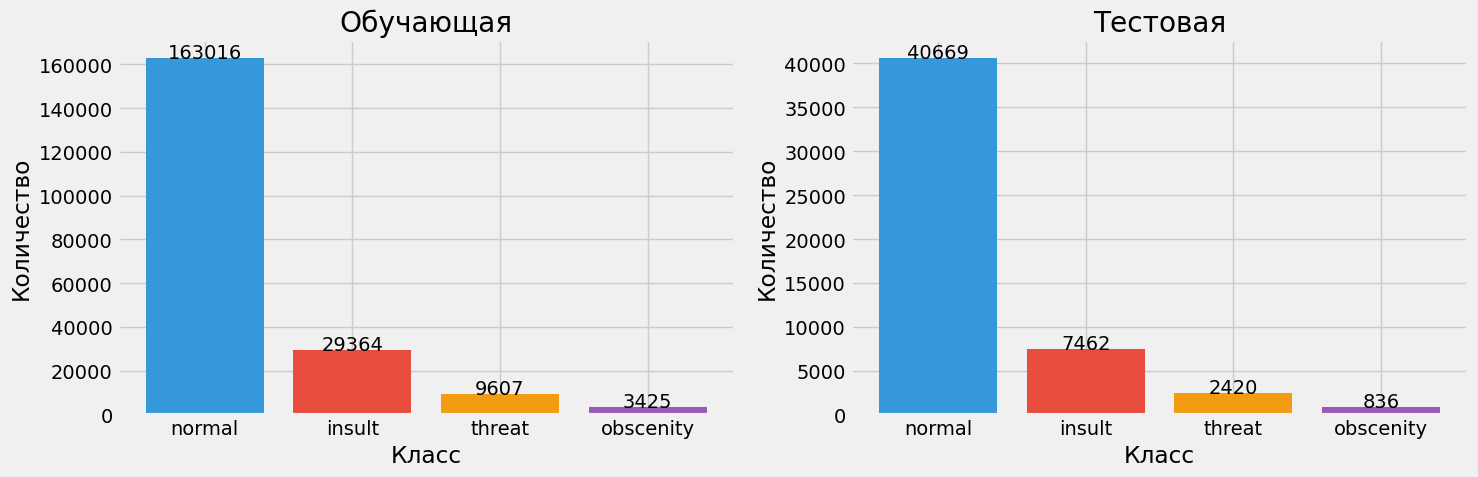

In [18]:
plt.style.use('fivethirtyeight')
colors = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Распределение в обучающей выборке
class_counts = df_train.iloc[:, 1:5].sum()
axes[0].bar(class_counts.index, class_counts.values, color=colors)
axes[0].set_title('Обучающая')
axes[0].set_xlabel('Название классов')
axes[0].set_ylabel('Кол-во')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center')

# Распределение в тестовой выборке
class_counts_test = df_test.iloc[:, 1:5].sum()
axes[1].bar(class_counts_test.index, class_counts_test.values, color=colors)
axes[1].set_title('Тестовая')
axes[1].set_xlabel('Название классов')
axes[1].set_ylabel('Кол-во')
for i, v in enumerate(class_counts_test.values):
    axes[1].text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

На графике можно увидеть что у 'normal' большое кол-во комментариев

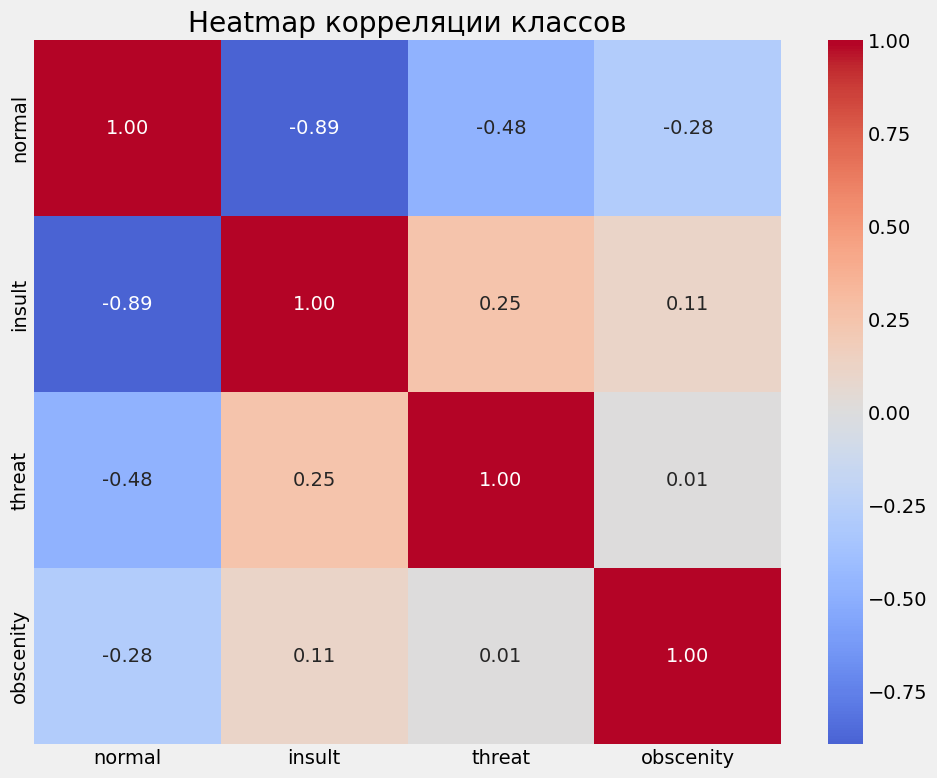

In [22]:
plt.figure(figsize=(10, 8))
numeric_cols = ['normal', 'insult', 'threat', 'obscenity']
correlation_matrix = df_train[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            xticklabels=numeric_cols, yticklabels=numeric_cols)
plt.title('Heatmap корреляции классов')
plt.tight_layout()
plt.show()

## Чтобы не было дисбаланса разделим нормальные и токсичные и сократим данные у нормальных

In [48]:
df_tox = df[df["normal"] == 0]
df_tox

,comment,normal,insult,threat,obscenity,lema_text
0,скотина! что сказать,0,1,0,0,скотина сказать
7,заколоть этого плешивого урода что бы крякнул ...,0,1,1,0,заколоть плешивый урод крякнуть селезень гандо...
24,долбоебы это фэйк,0,1,0,0,долбоеб это фэйк
25,"пиздаболы, сделали снимок, придумали историю и...",0,1,0,0,пиздабола сделать снимка придумать история под...
34,"мляяя..фомин..ты издесь умничаешь,чайка помойн...",0,1,0,0,мляять фомин издесь умничать чайка помойный су...
...,...,...,...,...,...,...
248265,"плохой актёр, поганый человек(если можно челов...",0,1,0,0,плохой актёр поганый человек человек назвать с...
248271,хохол он хуже пидараса ошслупь вонюч он бисмас...,0,1,0,0,хохол плохой пидарас ошслупь вонючий бисмасса ...
248274,сом вец ук сиар я поднял страну колен с асии и...,0,1,0,0,сом вец сиар поднять страна колено асий постав...
248280,на кол её !!!пилотка драная !!!у неё через рот...,0,1,1,0,кол пилотка драный рот асфальт видно


In [50]:
df_norm_tox = df.drop(df_tox.index, axis='index')
df_norm_tox

,comment,normal,insult,threat,obscenity,lema_text
1,я сегодня проезжала по рабочей и между домами ...,1,0,0,0,сегодня проезжать рабочий дом снитенко гомолыс...
2,очередной лохотрон. зачем придумывать очередно...,1,0,0,0,очередной лохотрон придумывать очередной налог...
3,"ретро дежавю ... сложно понять чужое сердце , ...",1,0,0,0,ретро дежавю сложно понять чужое сердце лиш ощ...
4,а когда мы статус агрогородка получили?,1,0,0,0,статус агрогородок получить
5,2 августа поздно вечером нашли вот такую потер...,1,0,0,0,август поздно вечером наслать такой потеряшка ...
...,...,...,...,...,...,...
248284,"это евгений леонов,а алексей леонов -космонавт.",1,0,0,0,это евгений леонов алексей леонов космонавт
248285,правильно всё по пять (5)...,1,0,0,0,правильно пять
248287,а у меня наверное рекорд в 1962 году в училище...,1,0,0,0,наверное рекорд год училище коренной зуб возмо...
248288,спасибо всем большое),1,0,0,0,спасибо весь большой


In [52]:
df_norm = df_norm_tox.sample(n=45000, random_state=42)
df_norm

,comment,normal,insult,threat,obscenity,lema_text
106030,почему вчера было так хорошо и почему сегодня ...,1,0,0,0,почему вчера почему сегодня плохо profile albu...
85531,они плохо учили историю.,1,0,0,0,плохо учить история
240329,"17/39 ужастное,позор тому кто ставил!!!",1,0,0,0,ужастной позор тот ставить
147203,"толку то, приехал чай попил и уехал",1,0,0,0,толк приехать чай попить уехать
245280,q с о в з о в и ваз zтто ле стнии грежим комме...,1,0,0,0,ваз zтто стнии грежим комментарий поделиться к...
...,...,...,...,...,...,...
6164,300 перевела,1,0,0,0,перевести
121422,а то все на нервах наверное сидят!,1,0,0,0,нерв наверное сидеть
103094,как ты будеш пенсионеркой чтоб с тобой сделать...,1,0,0,0,будеш пенсионерка ты сделать дожить пенсия пор...
185052,"возможно, у родителей ассоциальных, бездельник...",1,0,0,0,возможно родитель ассоциальный бездельник дом ...


In [54]:
df_comment = pd.concat([df_normal, df_toxic])
df_comment = df_comment.reset_index(drop=True)

In [56]:
%%time
df_comment.to_csv('nlp_comment_balance.csv', index=False)

CPU times: total: 375 ms
Wall time: 375 ms


# Нейройная модель

In [64]:
x_train_rnn, x_test_rnn, y_train_rnn, y_test_rnn = train_test_split(df_comment['lema_text'], df_comment['normal'], 
                                                                   test_size=0.21, random_state=19)

In [68]:
token_rnn = text.Tokenizer(num_words=40000)
token_rnn.fit_on_texts(x_train_rnn)

In [70]:
tk_train_sequences = token_rnn.texts_to_sequences(x_train_rnn)
tk_test_sequences = token_rnn.texts_to_sequences(x_test_rnn)

In [72]:
sq_train = sequence.pad_sequences(tk_train_sequences, maxlen=300)
sq_test = sequence.pad_sequences(tk_test_sequences, maxlen=300)

In [74]:
y_train_rnn_arr = np.array(y_train_rnn)
y_test_rnn_arr = np.array(y_test_rnn)

In [88]:
model_v3e = Sequential([
    Embedding(input_dim=40000, output_dim=128, input_length=300),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])

Модель уменьшает данные при этом отбрасывает ненужные информации и чтобы модель не переобучался, по итогу выдаст результат

In [90]:
model_v3e.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

In [92]:
model_v3e.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 300, 128)          5120000   
                                                                 
 bidirectional (Bidirectiona  (None, 128)              98816     
 l)                                                              
                                                                 
 dense (Dense)               (None, 32)                4128      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dropout_1 (Dropout)         (None, 16)                0         
                                                        

In [94]:
%%time
hst = model_v3e.fit(sq_train, y_train_rnn_arr, epochs=10, batch_size=256)

Epoch 1/10
277/277 [==============================] - 659s 2s/step - loss: 0.2391 - accuracy: 0.9068 - auc: 0.9654 - recall: 0.9121 - precision: 0.9029
Epoch 2/10
277/277 [==============================] - 721s 3s/step - loss: 0.0919 - accuracy: 0.9701 - auc: 0.9937 - recall: 0.9699 - precision: 0.9703
Epoch 3/10
277/277 [==============================] - 740s 3s/step - loss: 0.0519 - accuracy: 0.9827 - auc: 0.9977 - recall: 0.9839 - precision: 0.9816
Epoch 4/10
277/277 [==============================] - 751s 3s/step - loss: 0.0351 - accuracy: 0.9880 - auc: 0.9988 - recall: 0.9896 - precision: 0.9866
Epoch 5/10
277/277 [==============================] - 740s 3s/step - loss: 0.0258 - accuracy: 0.9913 - auc: 0.9993 - recall: 0.9928 - precision: 0.9899
Epoch 6/10
277/277 [==============================] - 738s 3s/step - loss: 0.0212 - accuracy: 0.9929 - auc: 0.9994 - recall: 0.9946 - precision: 0.9912
Epoch 7/10
277/277 [==============================] - 745s 3s/step - loss: 0.0207 - accu

In [96]:
%%time
loss, accuracy, auc, recall, precision = model_v3e.evaluate(sq_test, y_test_rnn_arr)

589/589 [==============================] - 14s 23ms/step - loss: 0.5055 - accuracy: 0.9302 - auc: 0.9604 - recall: 0.9575 - precision: 0.9093
CPU times: total: 1min 27s
Wall time: 14.2 s


In [98]:
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test loss: {loss:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")

Test Accuracy: 0.9302
Test loss: 0.5055
Recall: 0.9575
Precision: 0.9093


In [100]:
def model_predict_text_comment(text):
    test_text = token_rnn.texts_to_sequences(text)
    sq_test_text = sequence.pad_sequences(test_text, maxlen=max_length)
    y_pred_rnn = model_v3e.predict(sq_test_text, verbose = 1, batch_size = 2)
    
    sentiment = "Токсичный" if y_pred_rnn < 0.5 else "Не токсичный"
    confidence = y_pred_rnn if y_pred_rnn > 0.5 else 1 - y_pred_rnn
    return sentiment, confidence

In [102]:
text = ['привет как дела']
sentiment, confidence = model_predict_text_comment(text)
print(f"Тональность: {sentiment}\nВероятность: {confidence[0]}")

1/1 [==============================] - 1s 540ms/step
Тональность: Не токсичный
Вероятность: [1.]


In [104]:
text = ['иди в жопу тварь']
sentiment, confidence = model_predict_text_comment(text)
print(f"Тональность: {sentiment}\nВероятность: {confidence[0]}")

1/1 [==============================] - 0s 21ms/step
Тональность: Токсичный
Вероятность: [0.99999845]


# Сохраняем модель в файл

In [106]:
import pickle

In [108]:
model_v3e.save('model_v3e_nlp_comment.h5')

In [110]:
model_v3e.save_weights('model_v3e_nlp_comment.weights.h5')

In [112]:
# Сохранение модели
with open('keras_token_v3e_rnn_nlp.pkl', 'wb') as file:
    pickle.dump(token_rnn, file)